**Importing** **Modules**

In [36]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from lightgbm import LGBMClassifier

In [ ]:
df = pd.read_csv('data/onlinefraud.csv')

# **DATA UNDERSTANDING + CLEANING + FEATURE ENGINEERING**

In [38]:
df.head()
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
oldbalanceDest,0
newbalanceDest,0
isFraud,0


In [39]:
df = df.drop(["nameOrig", "nameDest"], axis=1)

df = pd.get_dummies(df, columns=["type"], drop_first=True, dtype=int)

In [40]:
df["balance_diff_orig"] = df["oldbalanceOrg"] - df["newbalanceOrig"]
df["balance_diff_dest"] = df["oldbalanceDest"] - df["newbalanceDest"]

df["amount_balance_ratio_orig"] = df["amount"] / (df["balance_diff_orig"] + 1)
df["balance_error"] = (df["oldbalanceOrg"] - df["amount"]) - df["newbalanceOrig"]

In [41]:
# Split Features and target

X = df.drop("isFraud", axis=1)
y = df["isFraud"]

In [42]:
# Train, test and split the data

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [45]:
# Imbalance Weight
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])
print(scale_pos_weight)

773.7482496194825


In [46]:
X_train

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFlaggedFraud,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,balance_diff_orig,balance_diff_dest,amount_balance_ratio_orig,balance_error
292779,15,9914.74,44248.00,34333.26,0.00,0.00,0,0,0,1,0,9914.74,0.00,0.999899,0.00
499763,20,6854.53,0.00,0.00,0.00,0.00,0,0,0,1,0,0.00,0.00,6854.530000,-6854.53
2970411,231,361211.80,0.00,0.00,489745.16,850956.95,0,1,0,0,0,0.00,-361211.79,361211.800000,-361211.80
3137549,236,7083.51,0.00,0.00,0.00,0.00,0,0,0,1,0,0.00,0.00,7083.510000,-7083.51
1500682,143,218019.51,13045685.58,13263705.09,2438123.98,2220104.47,0,0,0,0,0,-218019.51,218019.51,-1.000005,-436039.02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1524870,153,1895.99,0.00,0.00,0.00,0.00,0,0,0,1,0,0.00,0.00,1895.990000,-1895.99
5834821,402,347110.99,103785.00,0.00,87871.75,434982.74,0,1,0,0,0,103785.00,-347110.99,3.344488,-243325.99
4182953,304,13259.63,0.00,0.00,0.00,0.00,0,0,0,1,0,0.00,0.00,13259.630000,-13259.63
3985280,298,24122.92,0.00,0.00,0.00,0.00,0,0,0,1,0,0.00,0.00,24122.920000,-24122.92


In [47]:
model = LGBMClassifier(
    n_estimators=500,
    max_depth=8,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=773,
    learning_rate=0.05,
    random_state=42
)

model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 6570, number of negative: 5083526
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 1.390676 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2560
[LightGBM] [Info] Number of data points in the train set: 5090096, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.001291 -> initscore=-6.651247
[LightGBM] [Info] Start training from score -6.651247
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive 

LGBMClassifier(colsample_bytree=0.8, learning_rate=0.05, max_depth=8,
               n_estimators=500, num_leaves=64, random_state=42,
               scale_pos_weight=773, subsample=0.8)

In [49]:
y_pred_lg = model.predict(X_test)

print(classification_report(y_test, y_pred_lg))
print(confusion_matrix(y_test, y_pred_lg))
print(roc_auc_score(y_test, y_pred_lg))

              precision    recall  f1-score   support

           0       1.00      0.97      0.99   1270881
           1       0.04      0.98      0.08      1643

    accuracy                           0.97   1272524
   macro avg       0.52      0.98      0.53   1272524
weighted avg       1.00      0.97      0.98   1272524

[[1235789   35092]
 [     33    1610]]
0.9761512243291053


In [51]:
import numpy as np
from sklearn.metrics import confusion_matrix

thresholds = [0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]

y_prob = model.predict_proba(X_test)[:,1]

for t in thresholds:

    y_pred_thresh = (y_prob >= t).astype(int)

    cm = confusion_matrix(y_test, y_pred_thresh)

    print("Threshold:",t)
    print(cm)
    print()

Threshold: 0.2
[[1235789   35092]
 [     33    1610]]

Threshold: 0.3
[[1235789   35092]
 [     33    1610]]

Threshold: 0.4
[[1235789   35092]
 [     33    1610]]

Threshold: 0.5
[[1235789   35092]
 [     33    1610]]

Threshold: 0.6
[[1235789   35092]
 [     33    1610]]

Threshold: 0.7
[[1235789   35092]
 [     33    1610]]

Threshold: 0.8
[[1235789   35092]
 [     33    1610]]

Threshold: 0.9
[[1235789   35092]
 [     33    1610]]



In [54]:
print(y_prob.min())
print(y_prob.max())

np.unique(y_prob)

pd.Series(y_prob).describe()

0.0
1.0


,0
count,1.272524e+06
mean,2.884189e-02
std,1.673621e-01
min,0.000000e+00
25%,0.000000e+00
50%,0.000000e+00
75%,0.000000e+00
max,1.000000e+00


In [55]:
importance = model.feature_importances_

feat_imp = pd.DataFrame({
    "feature": X_train.columns,
    "importance": importance,
}).sort_values("importance", ascending=False)

print(feat_imp.head(15))

                      feature  importance
0                        step        2589
4              oldbalanceDest        1641
5              newbalanceDest        1453
12          balance_diff_dest        1308
14              balance_error        1244
1                      amount        1225
13  amount_balance_ratio_orig        1181
2               oldbalanceOrg        1100
11          balance_diff_orig         804
3              newbalanceOrig         503
7               type_CASH_OUT         162
10              type_TRANSFER         137
9                type_PAYMENT          22
8                  type_DEBIT           8
6              isFlaggedFraud           1


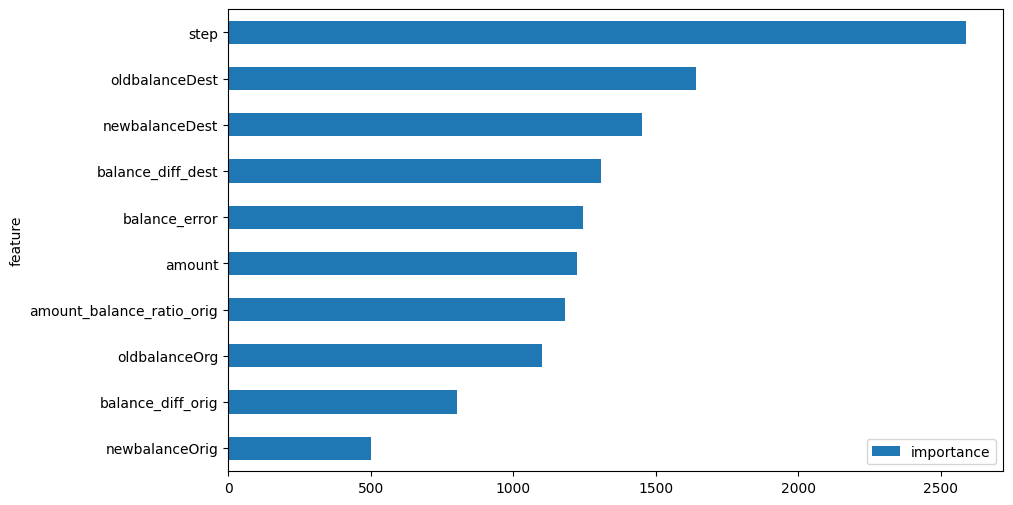

In [56]:
import matplotlib.pyplot as plt

feat_imp.head(10).plot(
    kind="barh",
    x="feature",
    y="importance",
    figsize=(10, 6),
)

plt.gca().invert_yaxis()
plt.show()

# SAVING THE TRAINED MODEL

In [57]:
import joblib

joblib.dump(model, 'lightgbm_fraud_model.pkl')

['lightgbm_fraud_model.pkl']

In [59]:
feature_columns = X_train.columns.tolist()

joblib.dump(feature_columns, "model_features.pkl")

['model_features.pkl']